In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Handle Data

In [ ]:
# Load data

df = pd.read_csv(r"Loan_Modelling.csv")

In [3]:
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
# get summary

df.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [ ]:
# check for duplicates, if any remove them

df.duplicated().sum()

np.int64(0)

In [ ]:
# drop identifiers

df.drop(["ID", "ZIPCode"], axis=1, inplace=True)

In [55]:
# from .describe() we have -ve experience
df[df["Experience"] < 0]['Experience'].count()

np.int64(0)

In [56]:
# correct experience since it can not be less than 0
# should we drop them or just use abs? ask Sam
df["Experience"] = df["Experience"].apply(lambda x: abs(x))

df[df["Experience"] < 0]['Experience'].count()


np.int64(0)

## Analysis

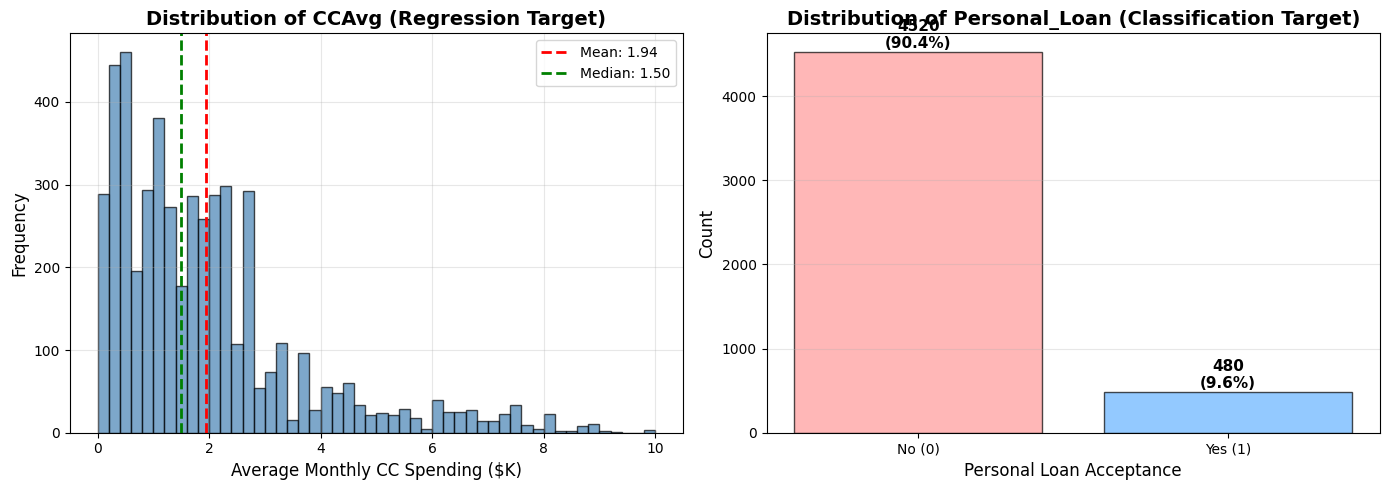


CCAvg Statistics:
  Mean: $1.94K
  Median: $1.50K
  Std Dev: $1.75K
  Range: $0.00K - $10.00K

Personal_Loan Statistics:
  Accepted (1): 480 (9.6%)
  Rejected (0): 4520 (90.4%)
  Class Imbalance Ratio: 1:9.4


In [50]:
# Analyze both target variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CCAvg distribution (Regression target)
axes[0].hist(df['CCAvg'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['CCAvg'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["CCAvg"].mean():.2f}')
axes[0].axvline(df['CCAvg'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["CCAvg"].median():.2f}')
axes[0].set_title('Distribution of CCAvg (Regression Target)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Monthly CC Spending ($K)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Personal_Loan distribution (Classification target)
loan_counts = df['Personal_Loan'].value_counts()
colors = ['#ff9999', '#66b3ff']
axes[1].bar(loan_counts.index, loan_counts.values, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Personal_Loan (Classification Target)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Personal Loan Acceptance', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No (0)', 'Yes (1)'])
axes[1].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, v in enumerate(loan_counts.values):
    axes[1].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCCAvg Statistics:")
print(f"  Mean: ${df['CCAvg'].mean():.2f}K")
print(f"  Median: ${df['CCAvg'].median():.2f}K")
print(f"  Std Dev: ${df['CCAvg'].std():.2f}K")
print(f"  Range: ${df['CCAvg'].min():.2f}K - ${df['CCAvg'].max():.2f}K")

print(f"\nPersonal_Loan Statistics:")
print(f"  Accepted (1): {loan_counts[1]} ({loan_counts[1]/len(df)*100:.1f}%)")
print(f"  Rejected (0): {loan_counts[0]} ({loan_counts[0]/len(df)*100:.1f}%)")
print(f"  Class Imbalance Ratio: 1:{loan_counts[0]/loan_counts[1]:.1f}")

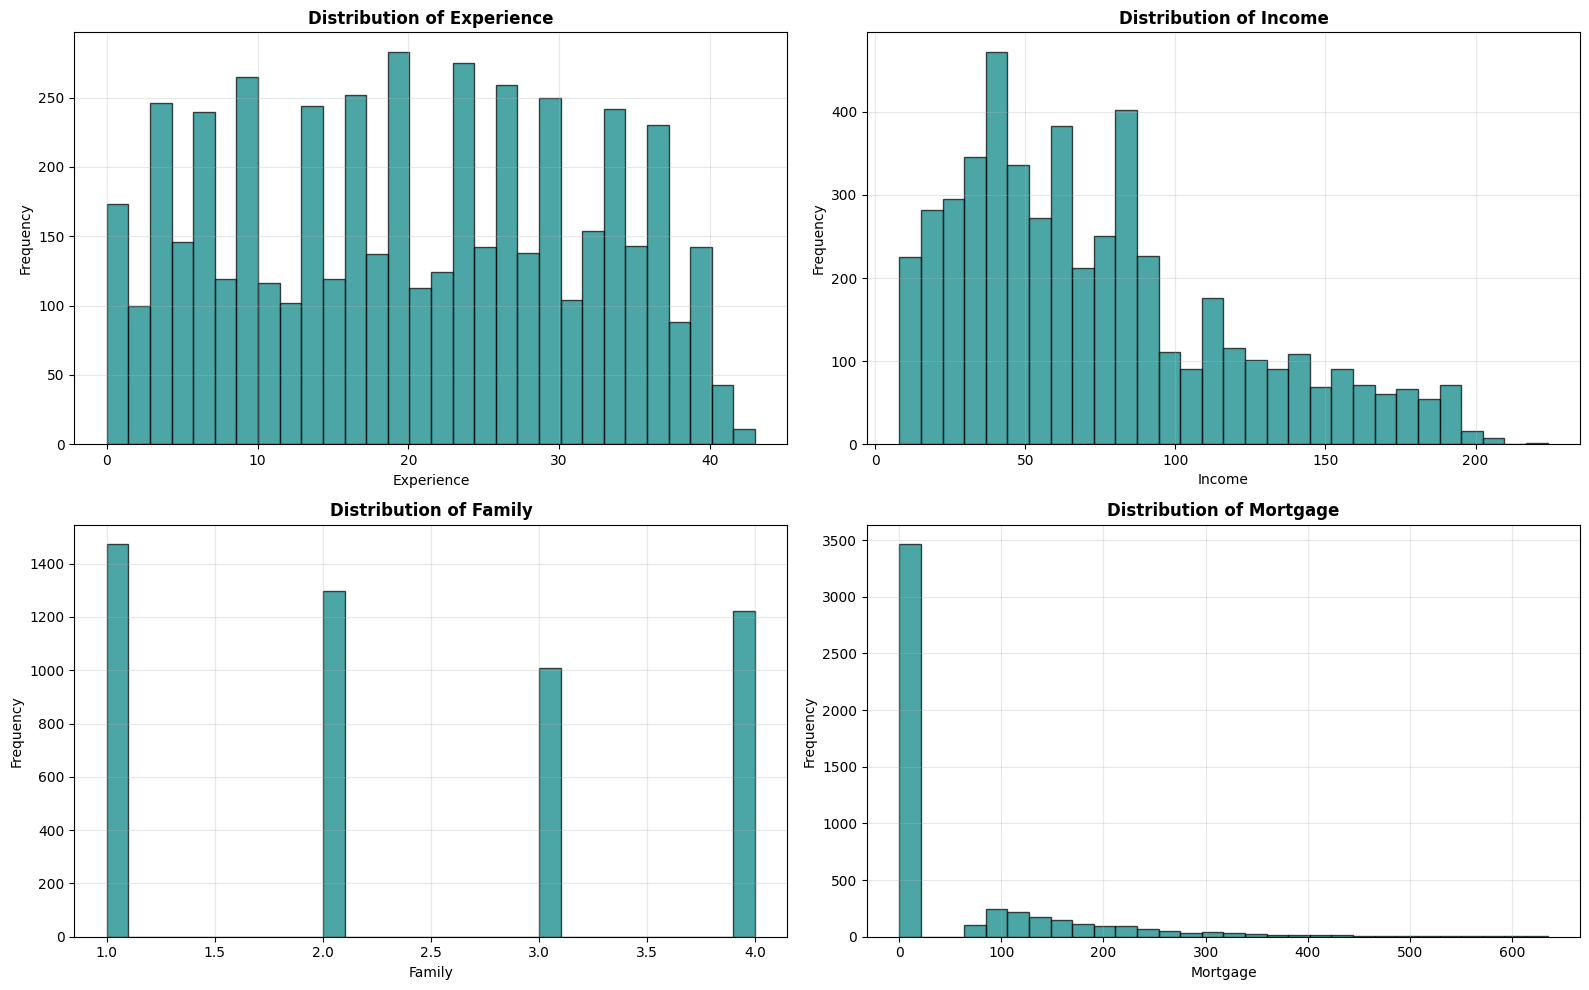

In [52]:
numerical_cols = ['Experience', 'Income', 'Family', 'Mortgage']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='teal')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

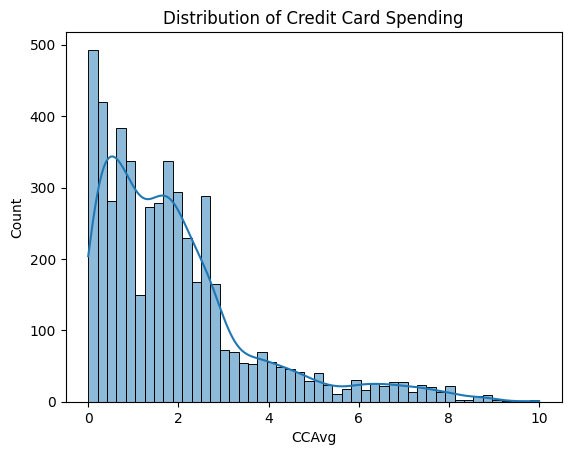

In [10]:
sns.histplot(df["CCAvg"], kde=True)
plt.title("Distribution of Credit Card Spending")
plt.show()

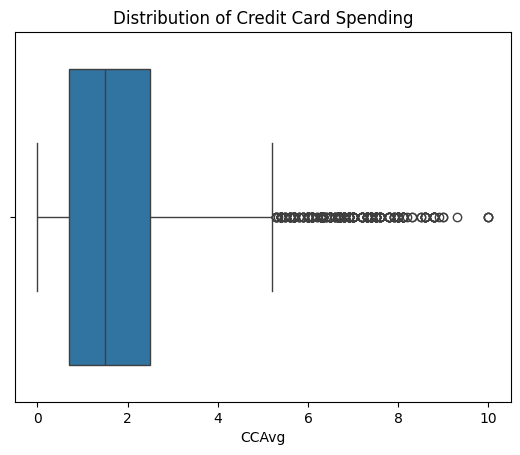

In [11]:
sns.boxplot(data=df, x=df["CCAvg"])
plt.title("Distribution of Credit Card Spending")
plt.show()

In [12]:
df["CCAvg"].describe()
df["CCAvg"].skew()

np.float64(1.5984433366678663)

In [13]:
df["Personal_Loan"].value_counts(normalize=True)

Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64

In [14]:
df.corr()["CCAvg"].sort_values(ascending=False)

CCAvg                 1.000000
Income                0.645984
Personal_Loan         0.366889
CD_Account            0.136534
Mortgage              0.109905
Securities_Account    0.015086
Online               -0.003611
CreditCard           -0.006689
Experience           -0.049738
Age                  -0.052012
Family               -0.109275
Education            -0.136124
Name: CCAvg, dtype: float64

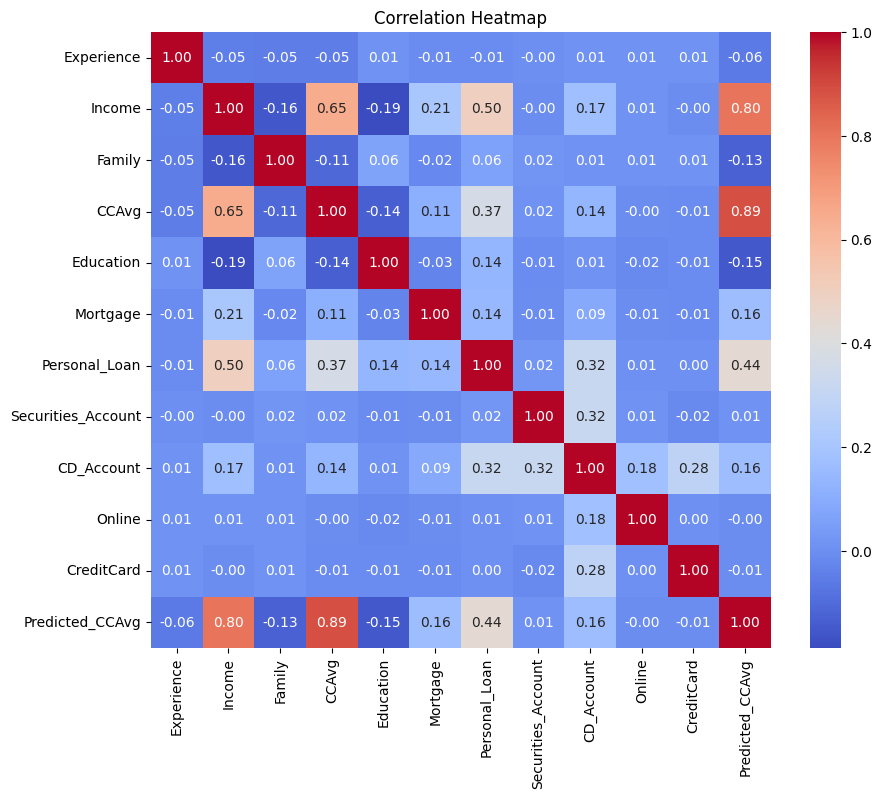

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Key EDA Conclusions for Regression


* Income is the dominant predictor.

* Spending behavior is strongly linked to financial capacity.

* Most demographic variables have weak linear effect.

* No extreme multicollinearity yet (need to check Age vs Experience).

In [16]:
df.corr()["Personal_Loan"].sort_values(ascending=False)

Personal_Loan         1.000000
Income                0.502462
CCAvg                 0.366889
CD_Account            0.316355
Mortgage              0.142095
Education             0.136722
Family                0.061367
Securities_Account    0.021954
Online                0.006278
CreditCard            0.002802
Age                  -0.007726
Experience           -0.008304
Name: Personal_Loan, dtype: float64

### Loan decision is driven more by financial capacity than demographics.

In [17]:
df[["Age","Experience"]].corr()

,Age,Experience
Age,1.000000,0.993991
Experience,0.993991,1.000000


## Severe multicollinearity

Age and Experience showed extremely high multicollinearity (correlation = 0.994). To prevent instability in regression coefficients, Age was removed from the model.

In [18]:
df.drop("Age", axis=1, inplace=True)

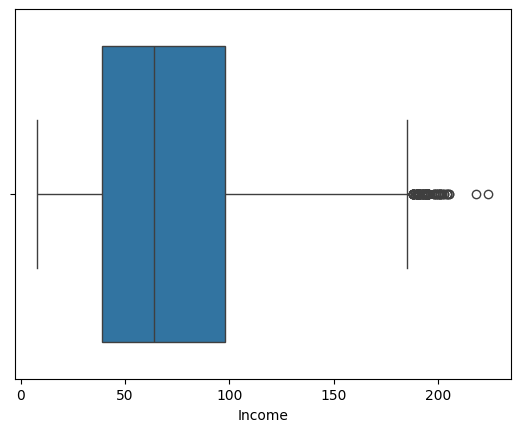

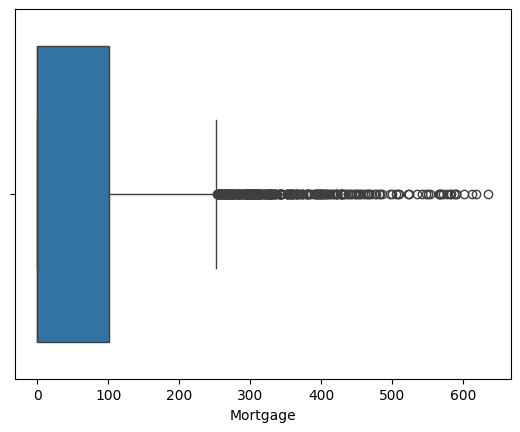

In [19]:
sns.boxplot(x=df["Income"])
plt.show()

sns.boxplot(x=df["Mortgage"])
plt.show()

In [20]:
df.head(n=1)

,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,49,4,1.6,1,0,0,1,0,0,0


# Regression

In [21]:
X_reg = df.drop(["CCAvg", "Personal_Loan"], axis=1)
y_reg = df["CCAvg"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("Features scaled using StandardScaler")
print(f"\nScaled training set mean: {X_train_scaled.mean():.6f}")
print(f"Scaled training set std: {X_train_scaled.std():.6f}")

Features scaled using StandardScaler

Scaled training set mean: 0.000000
Scaled training set std: 1.000000


In [24]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import numpy as np

y_test_pred = reg_model.predict(X_test_scaled)
y_train_pred = reg_model.predict(X_train_scaled)


print("Train RMSE:", np.sqrt(root_mean_squared_error(y_train, y_train_pred)))
print("Test RMSE:", np.sqrt(root_mean_squared_error(y_test, y_test_pred)))
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Train RMSE: 1.1552219807987403
Test RMSE: 1.1506753159833327
Train R2: 0.41791280799499964
Test R2: 0.4232572350287449


In [26]:
coeff_df = pd.DataFrame({
    "Feature": X_reg.columns,
    "Coefficient": reg_model.coef_
}).sort_values(by="Coefficient", ascending=False)

coeff_df

,Feature,Coefficient
1,Income,1.117772
6,CD_Account,0.058502
5,Securities_Account,0.006989
3,Education,-0.008044
4,Mortgage,-0.014234
2,Family,-0.015130
8,CreditCard,-0.018670
7,Online,-0.032845
0,Experience,-0.037736


In [27]:
X_full_scaled = scaler.transform(X_reg)
df["Predicted_CCAvg"] = reg_model.predict(X_full_scaled)

df[["CCAvg","Predicted_CCAvg"]].head()

,CCAvg,Predicted_CCAvg
0,1.6,1.448477
1,1.5,1.035320
2,1.0,0.489384
3,2.7,2.676397
4,1.0,1.254147


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_rf_train = rf.predict(X_train)
y_rf_test = rf.predict(X_test)

print("RF Train RMSE:", root_mean_squared_error(y_train, y_rf_train))
print("RF Test RMSE:", root_mean_squared_error(y_test, y_rf_test))

print("RF Train R2:", r2_score(y_train, y_rf_train))
print("RF Test R2:", r2_score(y_test, y_rf_test))

RF Train RMSE: 0.4947410501752569
RF Test RMSE: 1.301588497414931
RF Train R2: 0.9200014415013341
RF Test R2: 0.44266236319744157


In [29]:

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

              Feature  Importance
1              Income    0.585958
0          Experience    0.177089
4            Mortgage    0.071974
2              Family    0.056897
3           Education    0.042049
7              Online    0.023109
8          CreditCard    0.020124
5  Securities_Account    0.014287
6          CD_Account    0.008513


In [30]:
X_full_scaled = df.drop(["CCAvg", "Personal_Loan", "Predicted_CCAvg"], axis=1)

df["Predicted_CCAvg"] = rf.predict(X_full_scaled)

df[["CCAvg","Predicted_CCAvg"]].head()

,CCAvg,Predicted_CCAvg
0,1.6,1.72400
1,1.5,1.18400
2,1.0,0.78850
3,2.7,2.80350
4,1.0,0.91735


In [31]:
from sklearn.model_selection import train_test_split

X_clf = df.drop(["Personal_Loan", "CCAvg"], axis=1)
y_clf = df["Personal_Loan"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

In [32]:
X_clf.columns

Index(['Experience', 'Income', 'Family', 'Education', 'Mortgage',
       'Securities_Account', 'CD_Account', 'Online', 'CreditCard',
       'Predicted_CCAvg'],
      dtype='str')

In [33]:
# for LR and XGB
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_clf_scaled, y_train_clf)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [35]:

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

y_lr_test_pred = lr_model.predict(X_test_clf_scaled)
y_lr_train_pred = lr_model.predict(X_train_clf_scaled)

In [36]:
print("Training Metrics:")
print(f"Accuracy: {accuracy_score(y_train_clf, y_lr_train_pred):.4f}")
print(f"F1 Score: {f1_score(y_train_clf, y_lr_train_pred):.4f}")
print(f"Precision: {precision_score(y_train_clf, y_lr_train_pred):.4f}")
print(f"Recall: {recall_score(y_train_clf, y_lr_train_pred):.4f}")

print("\nClassification Report (Training):")
print(classification_report(y_train_clf, y_lr_train_pred))

Training Metrics:
Accuracy: 0.9514
F1 Score: 0.7099
Precision: 0.8320
Recall: 0.6190

Classification Report (Training):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3164
           1       0.83      0.62      0.71       336

    accuracy                           0.95      3500
   macro avg       0.90      0.80      0.84      3500
weighted avg       0.95      0.95      0.95      3500



In [37]:
print("Test Metrics:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_lr_test_pred):.4f}")
print(f"F1 Score: {f1_score(y_test_clf, y_lr_test_pred):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_lr_test_pred):.4f}")
print(f"Recall: {recall_score(y_test_clf, y_lr_test_pred):.4f}")

print("\nClassification Report (Training):")
print(classification_report(y_test_clf, y_lr_test_pred))

Test Metrics:
Accuracy: 0.9553
F1 Score: 0.7393
Precision: 0.8407
Recall: 0.6597

Classification Report (Training):
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1356
           1       0.84      0.66      0.74       144

    accuracy                           0.96      1500
   macro avg       0.90      0.82      0.86      1500
weighted avg       0.95      0.96      0.95      1500



In [38]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_clf, y_train_clf)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [39]:
y_dt_test_pred = dt_model.predict(X_test_clf)
y_dt_train_pred = dt_model.predict(X_train_clf)

In [40]:
print(classification_report(y_train_clf, y_dt_train_pred))
print('\n')
print(classification_report(y_test_clf, y_dt_test_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3164
           1       0.99      0.85      0.91       336

    accuracy                           0.98      3500
   macro avg       0.99      0.92      0.95      3500
weighted avg       0.98      0.98      0.98      3500



              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1356
           1       0.90      0.84      0.87       144

    accuracy                           0.98      1500
   macro avg       0.94      0.92      0.93      1500
weighted avg       0.98      0.98      0.98      1500



In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_clf, y_train_clf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [42]:
y_rf_test_pred = rf_model.predict(X_test_clf)
y_rf_train_pred = rf_model.predict(X_train_clf)

In [43]:
print(classification_report(y_train_clf, y_rf_train_pred))
print('\n')
print(classification_report(y_test_clf, y_rf_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3164
           1       1.00      1.00      1.00       336

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500



              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1356
           1       0.96      0.89      0.92       144

    accuracy                           0.99      1500
   macro avg       0.98      0.94      0.96      1500
weighted avg       0.99      0.99      0.99      1500



In [44]:
from xgboost import XGBClassifier

pos_count = (y_train_clf == 1).sum()
neg_count = (y_train_clf == 0).sum()

scale_pos_weight = neg_count/pos_count if pos_count > 0 else 1.0

xgb_model = XGBClassifier(
     n_estimators = 300,
    max_depth = 4,
    learning_rate = 0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective= 'binary:logistic',
    scale_pos_weight = scale_pos_weight,
    random_state = 42,
    n_jobs = -1
)

xgb_model.fit(X_train_clf_scaled, y_train_clf)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [45]:
y_xgb_test_pred = xgb_model.predict(X_test_clf_scaled)
y_xgb_train_pred = xgb_model.predict(X_train_clf_scaled)

In [46]:
print(classification_report(y_train_clf, y_xgb_train_pred))
print('\n')
print(classification_report(y_test_clf, y_xgb_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3164
           1       1.00      1.00      1.00       336

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500



              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1356
           1       0.86      0.92      0.89       144

    accuracy                           0.98      1500
   macro avg       0.93      0.95      0.94      1500
weighted avg       0.98      0.98      0.98      1500



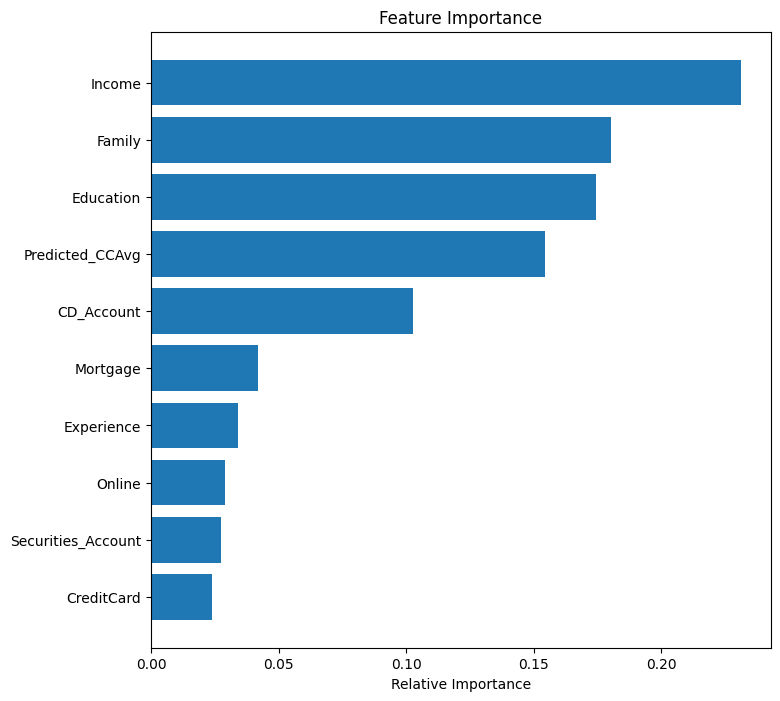

In [47]:

feature_names = list(X_train_clf)
feature_importances = xgb_model.feature_importances_
indicies = np.argsort(feature_importances)

plt.figure(figsize=(8,8))
plt.title("Feature Importance")
plt.barh(range(len(indicies)), feature_importances[indicies])
plt.yticks(range(len(indicies)), [feature_names[i] for i in indicies])
plt.xlabel("Relative Importance")
plt.show()